# Lecture 8 - Simulated annealing

### Optimization problem and Variational Monte Carlo
Optimization problems are very common in everyday life and we are always looking for mathematical techniques of search and optimization. The easiest optimization example is the fitting problem: given a function with different parameters, we try to fit it onto experimental data, then we search for the parameters which give to the best fit.
In some easy cases, an optimization can be considered as a minimization or a maximization problem. In physics many systems are governed by minimization principles, for example a system coupled to a reservoir always equilibrate
towards the state with minimal free energy.

Variational Monte Carlo is a powerful numerical method used to study quantum many-body systems. It combines the variational principle from quantum mechanics with the Metropolis Monte Carlo algorithm to approximate the ground-state properties of complex systems.

We start from the fact that any wave function $\psi_T$ gives an expectation value $E_T \geq E_0$ where $E_0$ is the ground-state energy
$$
E_T = \frac{\langle \psi_T | \hat{H} | \psi_T \rangle}{\langle \psi_T | \psi_T \rangle} = \frac{\int d\vec{r}_1 \dots d\vec{r}_N \psi_T^*(\vec{r}_1 \dots \vec{r}_N) \hat{H} \psi_T(\vec{r}_1 \dots \vec{r}_N)}{\int d\vec{r}_1 \dots d\vec{r}_N |\psi_T(\vec{r}_1 \dots \vec{r}_N)|^2} \ge E_0
$$
The goal is to minimize the $E_T$ by changing the parameters within a family of trial functions $\psi_T(a)$. 
In many-body systems, the integrals required to calculate $E_T$ are multidimensional (3N dimensions for $N$ particles). Traditional integration methods fail due to the "curse of dimensionality."McMillan (1965) observed that we can treat the square of the wave-function as a probability distribution:

$$
E_T = \frac{\langle \psi_T | \hat{H} | \psi_T \rangle}{\langle \psi_T | \psi_T \rangle} = \frac{\int d\vec{r}_1 \dots d\vec{r}_N \psi_T^*(\vec{r}_1 \dots \vec{r}_N) \hat{H} \psi_T(\vec{r}_1 \dots \vec{r}_N)}{\int d\vec{r}_1 \dots d\vec{r}_N |\psi_T(\vec{r}_1 \dots \vec{r}_N)|^2} \ge E_0
$$
By rewriting the energy integral, we can express $E_T$ as an average of a "local energy" $E_{loc}$ weighted by the probability distribution $P$
$$
E_T = \int d\vec{r}_1 \dots d\vec{r}_N P(\vec{r}_1 \dots \vec{r}_N) E_{loc}(\vec{r}_1 \dots \vec{r}_N)
$$
Where the local energy is defined as
$$
E_{loc}(\vec{R}) = \frac{\hat{H} \psi_T(\vec{R})}{\psi_T(\vec{R})}\ . 
$$
Given $\mathbf{x}=(x_1,\dots,x_n)$ a vector with $n$ elements which can take values in a either discrete or continuous domain, the most general optimization problem can be formalized as
$$
\text{Minimization of} \ \ L_1(\mathbf{x}), \dots, L_I(\mathbf{x})\ \  \text{subject to} \ \ h_j(\mathbf{x})=0\ \  \text{with} \ \ j=1,\dots,J\ \  \text{and} \ \ g_k(\mathbf{x})\leq 0 \ \ \text{with} \ \ k=1,\dots,K
$$
where $L_1(\mathbf{x}), \dots, L_I(\mathbf{x})$ are the loss or cost functions and $h_j,g_k$ are the equality and inequality constraints, respectively. The simplest case of optimization is unconstrained function optimization. In the case when $I=1$, it is called single-objective optimization problem. When $I\geq 2$, it becomes a multi-objective optimization problem.

To solve an optimization problem, efficient search or optimization algorithms are needed; these can be classified in many ways: for example gradient-based vs derivative-free algorithms or deterministic vs stochastic/euristic or local search vs global search. Some examples are gradient descent (batch, stochastic, mini-batch stochastic), random search, simulated annealing.


### Simulated Annealing
This algorithm is built as an analogy with thermodynamics in specific with the way that liquids freeze and crystallize, or metals cool and anneal. At high temperatures the molecules in a liquid move freely, as the temperature slowly cools down the mobility is progressively lowered. When this cooling down is slow the atoms are often able to line up and form a pure crystal, which is the state of minimum energy for the given system. We have to note that if a liquid is cooled quickly it does not reach this state but rather ends up in a polycrystalline or amorphous state having somewhat higher energy.

The idea of this optimization algorithm is to interpret the cost function $L(\mathbf{x})$, where $\mathbf{x}\in X^n$, as the energy of a statistical system and to consider the Boltzmann distribution 
$$
\rho(x) = \dfrac{1}{Z} e^{-\beta L(x)}
$$
In the low-temperature limit ($\beta \to \infty$), the distribution concentrates entirely on the global minima of $L(x)$, recovering the original optimization solution.

The process is a time-dependent Markov chain that follows an annealing schedule: $\{(\beta_1, n_1), (\beta_2, n_2), \dots, (\beta_N, n_N)\}$:
1. Initialization $\rightarrow$ we start at configuration $x_0$
2. Cycle $\rightarrow$ for each temperature step $i$ we run $n_i$ Monte Carlo steps at inverse temperature $\beta_i$, and the final configuration of cycle $i$ is used as the starting point for $i+1$.
3. Cooling $\rightarrow$ we gradually increase $\beta$ until the system relaxes into a minimum.

During each step, a new configuration $x'$ is generated from $x$, and the move is accepted with probability $P$ given by 
$$
P =
\begin{cases}
e^{-\beta (L(x') - L(x))} & \text{if } L(x') > L(x) \\
1 & \text{otherwise}
\end{cases}
$$
Downhill moves, so $L(x') \leq L(x)$, are always accepted, while uphill moves are accepted probabilistically, allowing the algorithm to jump out of local minima.

The effectiveness of the search depends on the temperature $T = 1/\beta$
| T | $\beta$ | Result |
| :--- | :--- | :---: |
| High | Small | Moves both with and against the gradient are accepted with nearly equal probability.|
| Low| Large | Only downhill moves are likely to be accepted.|

If the cooling is slow enough, so the ergodicity is achieved, the system drops into the global minimum. Due to finite simulation time, we typically reach a configuration close to the ground state, which is sufficient for most applications.

#### Parallel tempering
Sometimes when we try to perform low temperature simulations on rugged potential energy surfaces we may end up with our system stuck in a metastable configuration. The parallel tempering tries to overcome this problem by computing $n$ replicas of the system (with $n$ different temperatures) and in each of these a simulation in the canonical ensemble is performed.
The idea of parallel tempering is to include MC trial moves that attempt to swap systems that belong to different thermodynamic states. 
The acceptance rule of a swap between ensembles $i$ and $j$ follows from the condition of detailed balance and it turns out to be
$$
P = \text{min}\left(1, e^{-(\beta-j - \beta_i)(L(\mathbf{x}_i) - L(\mathbf{x}_j)))}\right)
$$
where $\beta_i$ and $L(\mathbf{x}_i)$ are the inverse temperatures and loss function of the i-th replica.
This probability tells us that if the temperature difference between the two systems is very large, the swap has a very low probability of being accepted instead of making attempts to swap between a low and a high temperature, we swap between ensembles with a small temperature difference. 


### Ground state of a 1D quantum particle
In this notebook we report the variational optimization the ground state of a single quantum particle in a one dimensional (1D) space confined by the following external potential:
$$
V(x) = x^4 - \frac{5}{2}x^2
$$
This 1D quantum model is not analytically solvable and should be attacked by numerical methods. In order to obtain an approximate wave function for the ground state, the Variational Monte Carlo method uses a trial wave function, parametrized by a set of variational parameters. An approximate model for the ground state wave function is the following trial wave function:
$$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$
$\Psi_T^{\sigma,\mu}(x)$ depends on two variational parameters: $\sigma$ and $\mu$.

### Supplementary material

How can we describe a wave function as a vector? We set up a lattice of discrete points, spaced by a constant distance $dx$, and record the value of the function at each lattice point. In this way the wave function, $\Psi(x)$ become a vector:

$$
\Psi(x) \to \left[ \Psi(x_1), \Psi(x_2), ..., \Psi(x_N) \right] = 
\left[ \Psi_1, \Psi_2, ..., \Psi_N \right]
$$

The time independent Schrodinger equation 

$$
{\hat H} \Psi(x) = \left( -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x) \right) \Psi(x) = E \Psi(x)
$$

can be written in matrix form. But how do we write the second derivative at a particular point? Let's start with the first derivatives:
$$
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) \simeq \frac{\Psi_{i+1}-\Psi_{i}}{dx}\\
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right) \simeq \frac{\Psi_{i}-\Psi_{i-1}}{dx}
$$

Thus, we can discretize the second derivative in the following way:
$$
\frac{\partial^2}{\partial x^2} \Psi(x=x_i) =
\frac{\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) - \frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right)}{dx} =
\frac{\Psi_{i+1}-2\Psi_{i}+\Psi_{i-1}}{dx^2}
$$

We finally obtain:

$$
\begin{bmatrix}
 \frac{\hbar^2}{m\,dx^2}+V(x_1)& -\frac{\hbar^2}{2m\,dx^2} & 0 & \dots  & 0 \\
-\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_2) & -\frac{\hbar^2}{2m\,dx^2} & \dots  & 0 \\
 0                        & -\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_3) & \dots  & 0 \\
 \vdots                   & \vdots                    & \vdots & \ddots & \vdots \\
 0                    & 0                & 0 & \dots  & \frac{\hbar^2}{m\,dx^2}+V(x_N)
\end{bmatrix}
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
= E
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
$$

To solve the time independent Schrodinger equation we therefore have to find eigenstates and eigenvalues of the matrix just obtained.

### Exercise 08.1

Write a Variational Monte Carlo code for a single quantum particle in 1D which exploits the Metropolis algorithm to sample the square modulus of our trial wave function $|\Psi_T^{\sigma,\mu}(x)|^2$ using an uniform transition probability $T(x_{new}|x_{old})$. By using data blocking, the code should be able to compute the expectation value for the Hamiltonian
$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
$$
which can be used to find the parameters that minimize this quantity. Use $\hbar=1$ and $m=1$. Note that the to measure $\langle \hat{H}\rangle_T$ you need the analytical calculation of
$$
\frac{{-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)}
$$

### Implementation - 08.1
The idea is to sample with the Metropolis algorithm
$$
\frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2}
$$
In fact the average hamiltonian can be written as
$$
\langle {\hat H} \rangle_T =
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)} = \displaystyle \int dx \ P(x) E_\text{loc}^T(x)
$$
where
- $\frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2}$ is the probability distribution function associated with the trial wavefunction $\psi_T(x)$
- $E_\text{loc}^T(x) = \dfrac{\hat{H}\psi_T(x)}{\psi_T(x)} = -\dfrac{1}{2}\dfrac{\psi''_T(x)}{\psi_T(x)} + V(x)$ is the local energy, the instantaneous energy value as a sum of kinetic and potential energies. This is computed in the code as `ave_hamiltonian`.

The code implements a Monte Carlo sampling for a given pair of parameters $(\mu,\sigma)$. The workflow, as previously seen, is 
1. Generation of a random displacement $x_\text{new} = x_\text{old} + \delta$ where $\delta$ is a uniformly drawn number: $\delta = $`rnd.Rannyu(-step,step)`, and the step size is set to $3$.
2. Calculation of the acceptance ratio $\min(1, \frac{|\Psi_T(x_{new})|^2}{|\Psi_T(x_{old})|^2})$
3. Acceptation or rejection of the move according to the condition `if (rnd.Rannyu() <= acceptance)` 

To handle the statistical correlation between consecutive steps the code uses the Data Blocking technique. In this case we performed $10^4$ steps divided into $100$ blocks, in each block the average energy is computed and then the progressive average and the statistical error using the standard deviation of the mean are obtained. 
The acceptance ratio is around $52\%$.


### Exercise 08.2

To find the parameters $\sigma$ and $\mu$ which minimize $\langle {\hat H} \rangle_T$, extend your Variational Monte Carlo code to face the variational optimization problem via a Simulated Annealing (SA) algorithm.

Choose an appropriate starting temperature for your SA algorithm and an appropriate temperature-update-law to make the optimization work.

Compute $\langle {\hat H} \rangle_T$ with enough statistics in order to be able to measure the lowering of $\langle {\hat H} \rangle_T$ once the variational parameters are moved.
- Show a picture of $\langle {\hat H} \rangle_T$ (with statistical uncertainties) as a function of the SA steps of the algorithm
- you could also show a picture of the trajectory of the SA algorithm in the variational parameter space as a function of the SA steps
- show a picture of the estimation of $\langle {\hat H} \rangle_T$  and its statistical uncertainty as a function of the number of blocks/MC steps for the set of parameters which minimize $\langle {\hat H} \rangle_T$
- show also a picture **of the sampled** $|\Psi_T(x)|^2$ by filling a histogram with the sampled configurations, moreover compare it with the analytic curve of $|\Psi_T(x)|^2$ and with the numerical solution obtained by transforming the Schrodinger equation into a matrix equation (see below the supplementary material).

### Implementation - 08.2
In this part we implemented Simulated Annealing algorithm in the code. Since we aim to mimics the process of slowly cooling a metal to reach the minimum energy state, we have to schedule the temperature, we chose to do it by designing the function `Temperature (int step)` which reads
$$
T(i) = \dfrac{3}{1 + 4i}
$$
where $i$ represents the step index, and so as the step increases the temperature drops. The initial temperature value is set to $3.0$.
At the first steps the temperature is higher and the system is able to explore the parameters' space widely. As the temperature is lowered the system accepts more likely moves that are lower in energy.

Inside the SA loop, the code proposes a new $\mu$ and $\sigma$ by shifting the current ones by a random amount `step`. It calculates the energy of the new configuration using the function `Metropolis_aveEnergy` which performs $M=10^5$ Monte Carlo steps starting from the origin with a step size of $2$ (this is the step size in the positions' space) as we have seen in the previous section. This function is a sort of inner cycle which moves in the $(x)$ coordinate space to calculate what the energy actually is for a fixed $(\mu, \sigma)$.

Then the Boltzmann weight is used to decide whether to accept the move or not: `min(1., exp(-1./T * (energy_new - energy_old)))`.
When the energy is lower is always accepted, while if it is higher it may be accepted with a probability that decreases as the temperature lowers.

A specific feature of this code is the adjustment of the step size of the parameters' search by checking the acceptance ratio $A$
- If $A < 40\%$ the step is decreased to the $90\%$ of its value in order to look more locally in the space.
- If $A > 60\%$ the step is increased to the $110\%$ of its value in order to look more widely in the space.

In the final part, once the parameters are optimized, the code runs a longer simulation of $10^6$ Monte Carlo steps to get a highly accurate final energy value and sample the probability density. Moreover the code performs the sampling of the distribution given the optimized parameters in order to compare the sampled and the analytical ones.

In the table below we report some key parameters and values
| Parameter | Value | Description |
| :--- | :--- | :---: |
| $n_T$ | 1000 | Number of temperature cooling steps|
| $n_\text{cycles}$ | 20 | Number of $(\mu,\sigma)$ pairs tested at each temperature value|
| $(\mu,\sigma)_\text{start}$ | $1.0$, $1.0$ | Initial parameters' values|




In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
plt.style.use('default')
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

In [13]:
# Python code to compute GS energy
#=============================================================================================================
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations


# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)


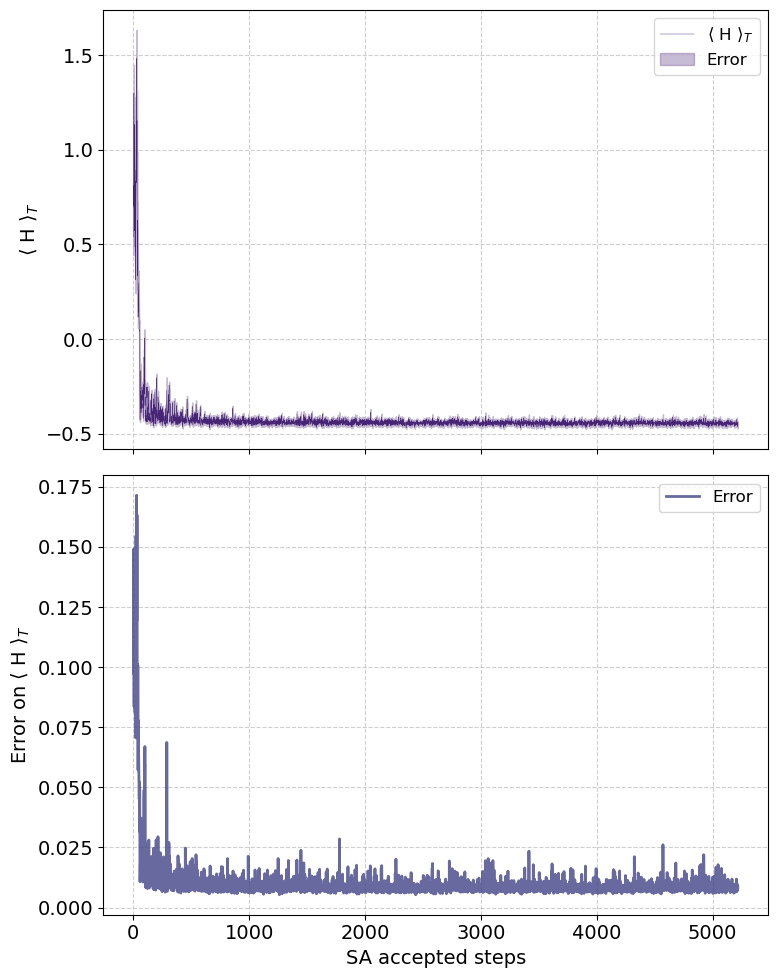

In [35]:
file1 = "ave_hamiltonian_sa_steps.data"
x1, y1, error1 = np.loadtxt(file1, usecols=(0, 3, 4), delimiter='\t', unpack=True, skiprows=1)
x2, y2 = np.loadtxt(file1, usecols=(0, 4), delimiter='\t', unpack=True, skiprows=1)

viridis = plt.cm.viridis
color_main = viridis(0.1)  
color_err_line = viridis(0.2)
fig, axes = plt.subplots(2, 1, figsize=(8, 10))


axes[0].plot(x1, y1, color=color_main, linewidth=0.3, label=rf'$\langle$ H $\rangle_T$')
axes[0].fill_between(x1, y1 - error1, y1 + error1, 
                     color=color_main, alpha=0.3, label='Error')
axes[0].set_ylabel(rf'$\langle$ H $\rangle_T$')
axes[0].tick_params(axis='x', labelbottom=False)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()


axes[1].plot(x2, y2, '-', color=color_err_line, alpha=0.8, label='Error')
axes[1].set_xlabel('SA accepted steps')
axes[1].set_ylabel(rf'Error on $\langle$ H $\rangle_T$')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

Simulated annealing algorithm
Results
σ = 0.618567
μ = 0.803221


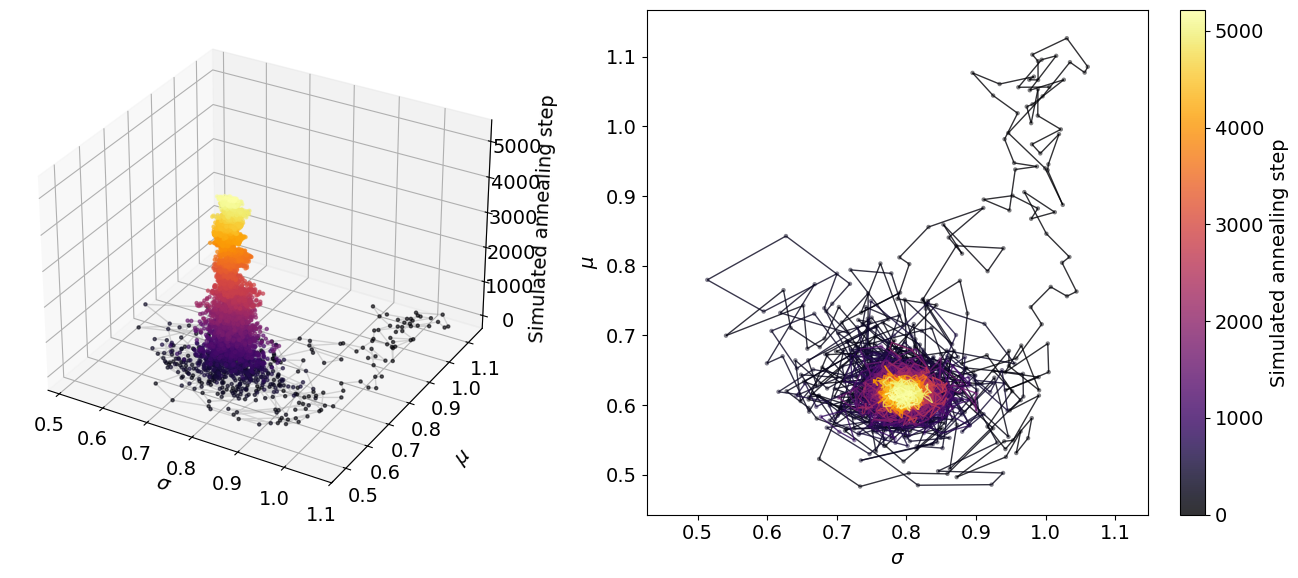

In [36]:
data = np.loadtxt("output_SA.txt")
data_2 = np.loadtxt("output_SA_accepted.txt", skiprows=1)

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2)

ax3d = fig.add_subplot(gs[0, 0], projection='3d')
x = data_2[:, 1] # sigma
y = data_2[:, 2] # mu
z = np.arange(len(data_2))
colors = plt.cm.inferno(np.linspace(0, 1, len(data_2)))

ax3d.scatter(x, y, z, c=z, cmap='inferno', s=5, alpha=0.6)
ax3d.plot(x, y, z, color='gray', alpha=0.3, lw=1) 

ax3d.set_xlabel(r"$\sigma$")
ax3d.set_ylabel(r"$\mu$", labelpad=15) 
ax3d.set_zlabel("Simulated annealing step")

ax2 = fig.add_subplot(gs[0, 1])
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = LineCollection(segments, cmap='inferno', array=z, linewidths=1., alpha=0.8)
line = ax2.add_collection(lc)
ax2.scatter(x, y, c=z, cmap='inferno', s=10, edgecolor='none', alpha=0.5)

ax2.set_xlabel(r"$\sigma$")
ax2.set_ylabel(r"$\mu$")
ax2.axis('equal')
ax2.set_xlim(x.min() - 0.1, x.max() + 0.1)
ax2.set_ylim(y.min() - 0.1, y.max() + 0.1)

cbar = fig.colorbar(line, ax=ax2)
cbar.set_label("Simulated annealing step")

best_mu = data[-1, 1]
best_sigma = data[-1, 2]
print("===================================================================")
print("Simulated annealing algorithm")
print("===================================================================")
print("Results")
print(f"σ = {best_sigma}")
print(f"μ = {best_mu}")
print("===================================================================")
plt.tight_layout()
plt.show()

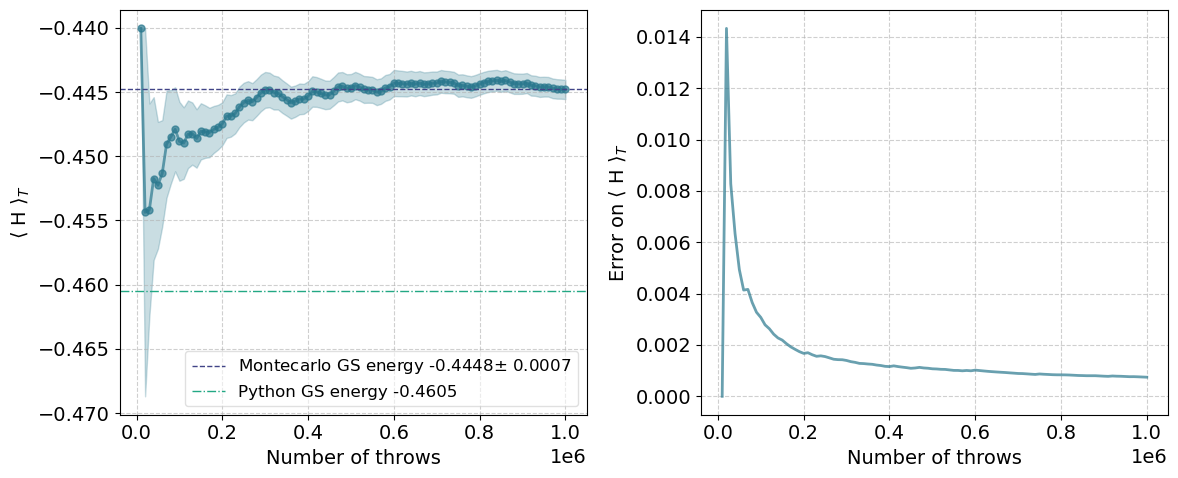

DIAGONALIZATION with PYTHON
Ground state energy:  -0.4604658796923901
1st excited state energy:  0.09742471331806084
2nd excited state energy:  1.9717331343935816
Montecarlo method
GS energy: -0.444795 ± 0.000745191


In [30]:
viridis = plt.cm.viridis
color_1 = viridis(0.2)
color_2 = viridis(0.4)
color_3 = viridis(0.6)

file_avg = "sampling.data"
x = np.loadtxt(file_avg, usecols=(0), delimiter='\t', unpack=True)
file_hamiltonian = "ave_hamiltonian.data"
x1,y1,error1 = np.loadtxt(file_hamiltonian, usecols=(0, 1, 2), delimiter='\t', unpack=True)
fig, axs = plt.subplots(1,2,figsize=(12, 5))

axs[0].plot(x1, y1, 'o-', color=color_2, alpha=0.7, markersize=5)
axs[0].fill_between(x1, y1-error1, y1+error1,
                       color=color_2, alpha=0.25)
axs[0].axhline(y=y1[99], color=color_1, linestyle='--', lw=1, label=rf'Montecarlo GS energy {y1[99]:.4f}$\pm$ {error1[99]:.4f}')
axs[0].axhline(y=E[0], color=color_3, linestyle='-.', lw=1, label=rf'Python GS energy {E[0]:.4f}')
axs[0].set_xlabel('Number of throws')
axs[0].set_ylabel(rf'$\langle$ H $\rangle_T$')
axs[0].legend(loc='lower right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[1].plot(x1, error1, '-', color=color_2, alpha=0.7)
axs[1].set_xlabel('Number of throws')
axs[1].set_ylabel(rf'Error on $\langle$ H $\rangle_T$')
axs[1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("===================================================================")
print("DIAGONALIZATION with PYTHON")
print("===================================================================")
print("Ground state energy: ", E[0])
print("1st excited state energy: ", E[1])
print("2nd excited state energy: ", E[2])
print("===================================================================")
print("Montecarlo method")
print("===================================================================")
print(f"GS energy: {y1[99]} \u00b1 {error1[99]}")
print("===================================================================")





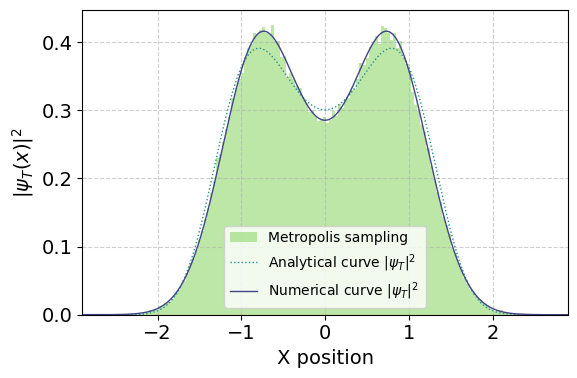

In [49]:
viridis = plt.cm.viridis
color_1 = viridis(0.2)
color_2 = viridis(0.5)
color_3 = viridis(0.8)

def psi_2(x, best_mu, best_sigma):
    return (np.exp(-(x-best_mu)**2/(2.0 * best_sigma**2)) + np.exp(-(x+best_mu)**2/(2.0 * best_sigma**2)))**2

file_avg = "sampling.data"
x = np.loadtxt(file_avg, usecols=(0), delimiter='\t', unpack=True)
x2 = np.linspace(-a/2, a/2, N)
file_hamiltonian = "ave_hamiltonian.data"
x1,y1,error1 = np.loadtxt(file_hamiltonian, usecols=(0, 1, 2), delimiter='\t', unpack=True)
fig, axs = plt.subplots(figsize=(6, 4))

axs.hist(x,bins=150, color=color_3, density=True, label = 'Metropolis sampling', alpha=0.5)
axs.plot(x2, psi[0]**2, color = color_2, label=r'Analytical curve $|\psi_T|^2$ ', lw=1., linestyle=':')
axs.plot(x2, psi_2(x2, 0.803221, 0.618567)/(a*np.mean(psi_2(x2, 0.803221, 0.618567))), lw=1.,color = color_1, label=r'Numerical curve $|\psi_T|^2$ ')
axs.set_xlabel(' X position ')
axs.set_ylabel(rf'$|\psi_T(x)|^2$')
axs.set_xlim(-2.9,2.9)
axs.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower center', fontsize=10)
plt.tight_layout()
plt.show()


